# Machine Learning Modeling for 30-Day Hospital Readmission Prediction

## Project Objective

The objective of this phase is to develop and evaluate machine learning models that predict whether a patient will be readmitted to the hospital within 30 days.

The target variable is:

`readmitted_30d`

- **0:** No readmission within 30 days
- **1:** Readmission within 30 days

The model-ready dataset was created during the previous feature engineering and feature selection phases.

### Modeling Dataset

- Total observations: **100,114**
- Final selected features: **39**
- Target variable: **1**
- Total modeling columns: **40**

### Modeling Approach

The machine learning workflow will include:

1. Loading and validating the model-ready dataset
2. Separating features and target
3. Performing a stratified train-validation-test split
4. Building a leakage-safe preprocessing pipeline
5. Establishing baseline models
6. Training advanced machine learning models
7. Addressing class imbalance
8. Hyperparameter tuning
9. Evaluating models using appropriate classification metrics
10. Selecting the final model
11. Evaluating the final model on the untouched test set
12. Interpreting feature importance and model behavior

Because the positive class represents approximately **11.34%** of the dataset, the target variable is imbalanced. Therefore, model performance will not be evaluated using accuracy alone.

## 1. Import Required Libraries

This section imports the libraries required for:

- Data manipulation
- Visualization
- Dataset splitting
- Feature preprocessing
- Machine learning modeling
- Class imbalance handling
- Hyperparameter optimization
- Model evaluation

In [68]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import (
    SimpleImputer
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

from sklearn.utils.class_weight import compute_sample_weight

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Model-Ready Dataset

The model-ready dataset contains the final set of features selected during the feature selection phase and the binary target variable.

The dataset is loaded independently from the processed data directory so that this notebook does not depend on variables from previous notebooks.

In [90]:
# ============================================================
# LOAD MODEL-READY DATASET
# ============================================================

DATA_PATH = Path("../Data/processed/diabetes_model_ready.csv")

df_model_Ml = pd.read_csv(DATA_PATH)

print("=" * 70)
print("MODEL-READY DATASET LOADED")
print("=" * 70)

print(f"\nDataset shape: {df_model_Ml.shape}")

print("\nFirst five rows:")
display(df_model_Ml.head())

MODEL-READY DATASET LOADED

Dataset shape: (100114, 40)

First five rows:


,race,gender,age,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,admission_source,diag_1_group,diag_2_group,diag_3_group,num_medications_active,num_medications_up,num_medications_down,num_medications_steady,weight_documented,readmitted_30d
0,Caucasian,Female,[0-10),1,Not_Documented,Pediatrics-Endocrinology,41,0,1,0,...,Physician Referral,"Endocrine, nutritional & metabolic diseases",Not_Documented,Not_Documented,0,0,0,0,0,0
1,Caucasian,Female,[10-20),3,Not_Documented,Not_Documented,59,0,18,0,...,Emergency Room,"Endocrine, nutritional & metabolic diseases","Endocrine, nutritional & metabolic diseases","Endocrine, nutritional & metabolic diseases",1,1,0,0,0,0
2,AfricanAmerican,Female,[20-30),2,Not_Documented,Not_Documented,11,5,13,2,...,Emergency Room,Pregnancy & childbirth,"Endocrine, nutritional & metabolic diseases",Supplementary factors (V-code),1,0,0,1,0,0
3,Caucasian,Male,[30-40),2,Not_Documented,Not_Documented,44,1,16,0,...,Emergency Room,Infectious & parasitic diseases,"Endocrine, nutritional & metabolic diseases",Circulatory diseases,1,1,0,0,0,0
4,Caucasian,Male,[40-50),1,Not_Documented,Not_Documented,51,0,8,0,...,Emergency Room,Neoplasms,Neoplasms,"Endocrine, nutritional & metabolic diseases",2,0,0,2,0,0


## 3. Validate the Modeling Dataset

Before splitting the dataset, basic validation checks are performed to confirm:

- The dataset contains the expected number of observations
- The expected number of features is present
- The target column exists
- The target is binary
- No duplicate columns are present
- The dataset does not contain duplicate rows

In [91]:
# ============================================================
# MODELING DATASET VALIDATION
# ============================================================

TARGET_COLUMN = "readmitted_30d"

print("=" * 70)
print("MODELING DATASET VALIDATION")
print("=" * 70)

print(f"\nDataset shape: {df_model_Ml.shape}")
print(f"Number of columns: {df_model_Ml.shape[1]}")

print("\nDuplicate rows:", df_model_Ml.duplicated().sum())
print("Duplicate columns:", df_model_Ml.columns.duplicated().sum())

print("\nTarget column exists:",
      TARGET_COLUMN in df_model_Ml.columns)

print("\nTarget values:")
print(df_model_Ml[TARGET_COLUMN].value_counts())

print("\nTarget distribution (%):")
print(
    df_model_Ml[TARGET_COLUMN]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Validation checks
assert TARGET_COLUMN in df_model_Ml.columns, \
    "ERROR — Target column is missing"

assert set(df_model_Ml[TARGET_COLUMN].unique()) == {0, 1}, \
    "ERROR — Target is not binary"

assert df_model_Ml.shape == (100114, 40), \
    "ERROR — Unexpected dataset shape"

assert df_model_Ml.columns.duplicated().sum() == 0, \
    "ERROR — Duplicate columns detected"

print("\n" + "=" * 70)
print("PASS — Dataset validation completed successfully")
print("=" * 70)

MODELING DATASET VALIDATION

Dataset shape: (100114, 40)
Number of columns: 40

Duplicate rows: 1
Duplicate columns: 0

Target column exists: True

Target values:
readmitted_30d
0    88757
1    11357
Name: count, dtype: int64

Target distribution (%):
readmitted_30d
0    88.66
1    11.34
Name: proportion, dtype: float64

PASS — Dataset validation completed successfully


## 3. Duplicate Row Inspection

One duplicate row was identified during dataset validation.

The duplicate rows are inspected before removal to confirm whether they represent exact duplicate observations. Exact duplicates can introduce unnecessary repetition during model training.

## 4. Feature and Target Separation

The dataset is separated into:

- `X` — the 39 predictor variables
- `y` — the binary 30-day readmission target

The target variable is excluded from the feature matrix to prevent target leakage.

In [92]:
# ============================================================
# FEATURE AND TARGET SEPARATION
# ============================================================

TARGET_COLUMN = "readmitted_30d"

X = df_model_Ml.drop(columns=[TARGET_COLUMN]).copy()

y = df_model_Ml[TARGET_COLUMN].copy()

print("=" * 70)
print("FEATURE AND TARGET SEPARATION")
print("=" * 70)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

print(f"\nNumber of features: {X.shape[1]}")

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget distribution (%):")
print(
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

FEATURE AND TARGET SEPARATION

Feature matrix shape: (100114, 39)
Target shape: (100114,)

Number of features: 39

Target distribution:
readmitted_30d
0    88757
1    11357
Name: count, dtype: int64

Target distribution (%):
readmitted_30d
0    88.66
1    11.34
Name: proportion, dtype: float64


## 5. Feature Type Identification

The selected features include both numerical and categorical variables.

Feature types are identified programmatically to build an appropriate preprocessing pipeline. Numerical features will be processed separately from categorical features.

In [93]:
# ============================================================
# IDENTIFY FEATURE TYPES
# ============================================================

numerical_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("=" * 70)
print("FEATURE TYPE SUMMARY")
print("=" * 70)

print(f"\nNumerical features ({len(numerical_features)}):")
for feature in numerical_features:
    print(f"  - {feature}")

print(f"\nCategorical features ({len(categorical_features)}):")
for feature in categorical_features:
    print(f"  - {feature}")

print(f"\nTotal features: {len(numerical_features) + len(categorical_features)}")

FEATURE TYPE SUMMARY

Numerical features (13):
  - time_in_hospital
  - num_lab_procedures
  - num_procedures
  - num_medications
  - number_outpatient
  - number_emergency
  - number_inpatient
  - number_diagnoses
  - num_medications_active
  - num_medications_up
  - num_medications_down
  - num_medications_steady
  - weight_documented

Categorical features (26):
  - race
  - gender
  - age
  - payer_code
  - medical_specialty
  - max_glu_serum
  - A1Cresult
  - metformin
  - repaglinide
  - nateglinide
  - glimepiride
  - glipizide
  - glyburide
  - pioglitazone
  - rosiglitazone
  - acarbose
  - insulin
  - glyburide-metformin
  - change
  - diabetesMed
  - admission_type
  - discharge_disposition
  - admission_source
  - diag_1_group
  - diag_2_group
  - diag_3_group

Total features: 39


## 6. Stratified Train, Validation, and Test Split

The dataset is divided into training, validation, and test sets.

Because the target variable is imbalanced, stratified sampling is used to preserve the proportion of 30-day readmissions across all datasets.

The split is:

- Training set: 70%
- Validation set: 15%
- Test set: 15%

The test set will remain untouched during model selection and will be used only for final model evaluation.

In [ ]:
df_patient_nbr = pd.read_csv("../Data/Processed/Diabetes_orginal_file.csv")


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,num_medications_down,num_medications_steady,medication_changed,diabetes_medication_used,weight_documented,max_glu_serum_level,max_glu_serum_documented,A1C_level,A1C_documented,death_related_disposition
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,0,0,0,0,0,NaN,0,NaN,0,0
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,0,0,1,1,0,NaN,0,NaN,0,0
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,0,1,0,1,0,NaN,0,NaN,0,0
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,0,0,1,1,0,NaN,0,NaN,0,0
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,0,2,1,1,0,NaN,0,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100109,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,1,1,1,1,0,NaN,0,2.0,1,0
100110,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,0,1,0,1,0,NaN,0,NaN,0,0
100111,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,...,1,1,1,1,0,NaN,0,NaN,0,0
100112,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,...,0,2,1,1,0,NaN,0,NaN,0,0


In [114]:
# ============================================================
# VALIDATE DATASET ALIGNMENT
# ============================================================

print("=" * 70)
print("DATASET ALIGNMENT VALIDATION")
print("=" * 70)

print("\ndf_model_Ml shape:", df_model_Ml.shape)
print("df_patient_nbr shape:", df_patient_nbr.shape)

# Extract patient identifiers
groups_pbnr= df_patient_nbr["patient_nbr"].copy()

print("\nPatient groups shape:", groups_pbnr.shape)

# Validation
assert len(df_model_Ml) == len(groups_pbnr), \
    "ERROR — Modeling dataset and patient IDs have different row counts"

assert df_model_Ml.index.equals(groups_pbnr.index), \
    "ERROR — Modeling dataset and patient IDs are not index-aligned"

print("\nPASS — Row counts are identical")
print("PASS — Row indexes are aligned")
print("PASS — Patient identifiers are ready for group-based splitting")

print("=" * 70)

DATASET ALIGNMENT VALIDATION

df_model_Ml shape: (100114, 40)
df_patient_nbr shape: (100114, 67)

Patient groups shape: (100114,)

PASS — Row counts are identical
PASS — Row indexes are aligned
PASS — Patient identifiers are ready for group-based splitting


In [117]:
# ============================================================
# DEFINE FEATURES, TARGET, AND GROUPS
# ============================================================

TARGET_COLUMN = "readmitted_30d"

# Features
X = df_model_Ml.drop(columns=[TARGET_COLUMN]).copy()

# Target
y = df_model_Ml[TARGET_COLUMN].copy()

# Patient grouping variable
groups_pbnr = df_patient_nbr["patient_nbr"].copy()

print("=" * 70)
print("FEATURE, TARGET, AND GROUP SUMMARY")
print("=" * 70)

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("groups_pbnr shape:", groups_pbnr.shape)

print("\nUnique patients:", groups_pbnr.nunique())
print("Total encounters:", len(groups_pbnr))

print("\nTarget distribution:")
print(y.value_counts())

# Final validation
assert len(X) == len(y) == len(groups_pbnr), \
    "ERROR — X, y, and groups have different lengths"

assert X.index.equals(y.index), \
    "ERROR — X and y indexes are not aligned"

assert X.index.equals(groups_pbnr.index), \
    "ERROR — X and patient groups are not aligned"

assert "patient_nbr" not in X.columns, \
    "ERROR — patient_nbr must not be included as a model feature"

print("\nPASS — X, y, and groups are correctly prepared")
print("PASS — patient_nbr is excluded from model features")

print("=" * 70)

FEATURE, TARGET, AND GROUP SUMMARY

X shape: (100114, 39)
y shape: (100114,)
groups_pbnr shape: (100114,)

Unique patients: 70439
Total encounters: 100114

Target distribution:
readmitted_30d
0    88757
1    11357
Name: count, dtype: int64

PASS — X, y, and groups are correctly prepared
PASS — patient_nbr is excluded from model features


# Train-Test Split Using Patient-Level Grouping

The dataset contains multiple hospital encounters for some patients.

A standard random train-test split could place encounters from the same patient
in both the training and testing datasets. This could lead to patient-level
data leakage and overly optimistic model performance.

To prevent this, `patient_nbr` is used as a grouping variable with
`GroupShuffleSplit`.

This ensures that all encounters belonging to a particular patient are assigned
exclusively to either the training set or the testing set.

The `patient_nbr` column is used only for splitting and is not included as a
machine learning feature.

In [119]:
from sklearn.model_selection import GroupShuffleSplit



# ============================================================
# GROUP-BASED TRAIN-TEST SPLIT
# ============================================================

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(X, y, groups=groups_pbnr)
)
# ============================================================
# CREATE TRAIN AND TEST DATASETS
# ============================================================

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups_pbnr.iloc[train_idx].copy()
groups_test = groups_pbnr.iloc[test_idx].copy()

In [124]:
# ============================================================
# TRAIN-TEST SPLIT SUMMARY
# ============================================================

print("=" * 70)
print("GROUP-BASED TRAIN-TEST SPLIT SUMMARY")
print("=" * 70)

print(f"\nFull dataset rows: {len(X):,}")

print(f"\nTraining rows: {len(X_train):,}")
print(f"Testing rows:  {len(X_test):,}")

print(f"\nTraining percentage: {len(X_train) / len(X) * 100:.2f}%")
print(f"Testing percentage:  {len(X_test) / len(X) * 100:.2f}%")

print("\n" + "=" * 70)
print("FEATURE AND TARGET SHAPES")
print("=" * 70)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

print(f"\ny_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

print("\n" + "=" * 70)
print("UNIQUE PATIENTS")
print("=" * 70)

print(f"\nTotal unique patients: {groups_pbnr.nunique():,}")
print(f"Training patients:     {groups_train.nunique():,}")
print(f"Testing patients:      {groups_test.nunique():,}")



GROUP-BASED TRAIN-TEST SPLIT SUMMARY

Full dataset rows: 100,114

Training rows: 80,039
Testing rows:  20,075

Training percentage: 79.95%
Testing percentage:  20.05%

FEATURE AND TARGET SHAPES

X_train shape: (80039, 39)
X_test shape:  (20075, 39)

y_train shape: (80039,)
y_test shape:  (20075,)

UNIQUE PATIENTS

Total unique patients: 70,439
Training patients:     56,351
Testing patients:      14,088


In [125]:
# ============================================================
# PATIENT OVERLAP VALIDATION
# ============================================================

train_patients = set(groups_train.unique())
test_patients = set(groups_test.unique())

patient_overlap = train_patients.intersection(test_patients)

print("=" * 70)
print("PATIENT OVERLAP VALIDATION")
print("=" * 70)

print(f"\nUnique training patients: {len(train_patients):,}")
print(f"Unique testing patients:  {len(test_patients):,}")
print(f"Overlapping patients:     {len(patient_overlap):,}")

assert len(patient_overlap) == 0, \
    "ERROR — Some patients appear in both training and testing data"

print("\nPASS — No patient appears in both training and testing datasets")
print("=" * 70)

PATIENT OVERLAP VALIDATION

Unique training patients: 56,351
Unique testing patients:  14,088
Overlapping patients:     0

PASS — No patient appears in both training and testing datasets


In [126]:
# ============================================================
# TARGET DISTRIBUTION
# ============================================================

print("=" * 70)
print("TARGET DISTRIBUTION AFTER SPLITTING")
print("=" * 70)

print("\nFULL DATASET:")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nTRAINING DATA:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTESTING DATA:")
print((y_test.value_counts(normalize=True) * 100).round(2))

TARGET DISTRIBUTION AFTER SPLITTING

FULL DATASET:
readmitted_30d
0    88.66
1    11.34
Name: proportion, dtype: float64

TRAINING DATA:
readmitted_30d
0    88.69
1    11.31
Name: proportion, dtype: float64

TESTING DATA:
readmitted_30d
0    88.52
1    11.48
Name: proportion, dtype: float64


In [127]:
# ============================================================
# PATIENT LEAKAGE VALIDATION
# ============================================================

train_patients = set(groups_train)
test_patients = set(groups_test)

common_patients = train_patients.intersection(test_patients)

print("=" * 70)
print("PATIENT LEAKAGE VALIDATION")
print("=" * 70)

print(f"\nUnique patients in training set: {len(train_patients):,}")
print(f"Unique patients in testing set:  {len(test_patients):,}")

print(f"\nPatients appearing in both sets: {len(common_patients)}")

assert len(common_patients) == 0, \
    "ERROR — Patient leakage detected between training and testing sets"

print("\nPASS — No patient appears in both training and testing sets")
print("=" * 70)

PATIENT LEAKAGE VALIDATION

Unique patients in training set: 56,351
Unique patients in testing set:  14,088

Patients appearing in both sets: 0

PASS — No patient appears in both training and testing sets


# 3. Machine Learning Preprocessing Pipeline

After completing the patient-level train-test split and validating that no patient appears in both datasets, the next step is to prepare the features for machine learning.

The preprocessing pipeline will handle numerical and categorical features separately.

## Numerical Features

Numerical features will be:

1. Imputed using the median if missing values exist
2. Scaled using `StandardScaler`

## Categorical Features

Categorical features will be:

1. Imputed using the most frequent category if missing values exist
2. Encoded using `OneHotEncoder`

The transformations will be combined using `ColumnTransformer`.

All preprocessing will be fitted only on the training data to prevent data leakage. The same learned transformations will then be applied to the testing data.

In [128]:
# ============================================================
# MISSING VALUE CHECK
# ============================================================

print("=" * 70)
print("MISSING VALUE CHECK")
print("=" * 70)

train_missing = X_train.isnull().sum()
test_missing = X_test.isnull().sum()

print("\nTraining data missing values:")
print(train_missing[train_missing > 0])

print("\nTesting data missing values:")
print(test_missing[test_missing > 0])

print("\nTotal missing values in training data:",
      train_missing.sum())

print("Total missing values in testing data:",
      test_missing.sum())

print("=" * 70)

MISSING VALUE CHECK

Training data missing values:
Series([], dtype: int64)

Testing data missing values:
Series([], dtype: int64)

Total missing values in training data: 0
Total missing values in testing data: 0


In [129]:
# ============================================================
# IMPORT PREPROCESSING TOOLS
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

In [130]:
# ============================================================
# NUMERICAL PREPROCESSING PIPELINE
# ============================================================

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

print("Numerical preprocessing pipeline created successfully")

Numerical preprocessing pipeline created successfully


In [131]:
# ============================================================
# CATEGORICAL PREPROCESSING PIPELINE
# ============================================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

print("Categorical preprocessing pipeline created successfully")

Categorical preprocessing pipeline created successfully


In [132]:
# ============================================================
# COMPLETE PREPROCESSING PIPELINE
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print("=" * 70)
print("PREPROCESSING PIPELINE CREATED")
print("=" * 70)

print(f"\nNumerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total original features: {len(numerical_features) + len(categorical_features)}")

PREPROCESSING PIPELINE CREATED

Numerical features: 13
Categorical features: 26
Total original features: 39


## 4. Baseline Model — Dummy Classifier

Before training real machine learning models, a Dummy Classifier is used to establish a baseline.

The Dummy Classifier does not learn meaningful relationships between the features and the target. Instead, it makes predictions using a simple predefined strategy.

This baseline is important because the target variable is imbalanced:

- 0: No readmission within 30 days
- 1: Readmission within 30 days

A model must outperform the Dummy Classifier to demonstrate that it has learned useful predictive patterns.


In [136]:

#import the libray for the Dummyclassifer
from sklearn.dummy import DummyClassifier

# ============================================================
# DUMMY CLASSIFIER BASELINE
# ============================================================


dummy_model = DummyClassifier(
    strategy='most_frequent'
)

# Train baseline model

dummy_model.fit(X_train,y_train)

# Predictions
y_pred_dummy = dummy_model.predict(X_test)

print(F'y_pred_dummy :{y_pred_dummy}')
print("Dummy Classifier trained successfully")

y_pred_dummy :[0 0 0 ... 0 0 0]
Dummy Classifier trained successfully


In [137]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

dummy_accuracy = accuracy_score(
    y_test,
    y_pred_dummy
)

dummy_precision = precision_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)

dummy_recall = recall_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)

dummy_f1 = f1_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)

print("=" * 70)
print("DUMMY CLASSIFIER PERFORMANCE")
print("=" * 70)

print(f"\nAccuracy:  {dummy_accuracy:.4f}")
print(f"Precision: {dummy_precision:.4f}")
print(f"Recall:    {dummy_recall:.4f}")
print(f"F1 Score:  {dummy_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_dummy,
        zero_division=0
    )
)

DUMMY CLASSIFIER PERFORMANCE

Accuracy:  0.8852
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17770
           1       0.00      0.00      0.00      2305

    accuracy                           0.89     20075
   macro avg       0.44      0.50      0.47     20075
weighted avg       0.78      0.89      0.83     20075



## 5. Logistic Regression Baseline

Logistic Regression is used as the first real machine learning model for predicting 30-day hospital readmission.

Unlike the Dummy Classifier, Logistic Regression learns relationships between the selected patient, hospital encounter, laboratory, diagnosis, and medication features and the target variable.

Because the dataset contains both numerical and categorical features, preprocessing is required before model training.

- Numerical features will be imputed and standardized.
- Categorical features will be imputed and one-hot encoded.

The preprocessing steps will be fitted only on the training data. The fitted transformations will then be applied to the testing data to prevent data leakage.

In [138]:
# ============================================================
# MISSING VALUE CHECK
# ============================================================

print("=" * 70)
print("MISSING VALUE CHECK")
print("=" * 70)

train_missing = X_train.isnull().sum()
test_missing = X_test.isnull().sum()

print("\nTRAINING DATA")
print("-" * 70)

if train_missing.sum() == 0:
    print("PASS — No missing values found")
else:
    print(train_missing[train_missing > 0])

print("\nTESTING DATA")
print("-" * 70)

if test_missing.sum() == 0:
    print("PASS — No missing values found")
else:
    print(test_missing[test_missing > 0])

print("\nTotal missing values:")
print(f"Training: {train_missing.sum():,}")
print(f"Testing:  {test_missing.sum():,}")

print("=" * 70)

MISSING VALUE CHECK

TRAINING DATA
----------------------------------------------------------------------
PASS — No missing values found

TESTING DATA
----------------------------------------------------------------------
PASS — No missing values found

Total missing values:
Training: 0
Testing:  0


# 4. Logistic Regression — Baseline Model

Logistic Regression will be used as the first real machine learning baseline model.

The Dummy Classifier established a baseline accuracy of approximately 88.5%, but it predicted only the majority class and completely failed to identify 30-day readmissions.

For this project, Logistic Regression will provide:

- A simple and interpretable baseline
- Probability estimates for readmission
- A benchmark for more complex models
- A better understanding of the impact of class imbalance

Because the dataset contains both numerical and categorical features, preprocessing will be applied separately to each feature type.

The model will be evaluated primarily using:

- Precision
- Recall
- F1-score
- ROC-AUC

Accuracy will also be reported, but it will not be treated as the primary evaluation metric because the target variable is imbalanced.

In [140]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    confusion_matrix
)

In [142]:
# ============================================================
# LOGISTIC REGRESSION BASELINE
# ============================================================

logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)


# ============================================================
# COMPLETE LOGISTIC REGRESSION PIPELINE
# ============================================================

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            logistic_model
        )
    ]
)


# ============================================================
# TRAIN LOGISTIC REGRESSION
# ============================================================

logistic_pipeline.fit(
    X_train,
    y_train
)

print("=" * 70)
print("LOGISTIC REGRESSION TRAINING COMPLETED")
print("=" * 70)

LOGISTIC REGRESSION TRAINING COMPLETED


# 5. Logistic Regression — Model Evaluation

After training the Logistic Regression model, predictions will be generated on the unseen test dataset.

The model will be evaluated using multiple metrics because the target variable is imbalanced.

Primary evaluation metrics:

- Recall — ability to identify actual 30-day readmissions
- Precision — reliability of predicted readmissions
- F1-score — balance between precision and recall
- ROC-AUC — ability to distinguish between the two classes

Accuracy will also be reported, but it should not be considered the primary metric because approximately 88.66% of observations belong to the non-readmission class.

In [143]:
# ============================================================
# GENERATE TEST SET PREDICTIONS
# ============================================================

# Class predictions
y_pred_logistic = logistic_pipeline.predict(X_test)

# Probability of readmission within 30 days
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

print("=" * 70)
print("LOGISTIC REGRESSION PREDICTIONS GENERATED")
print("=" * 70)

print("\nPrediction shape:", y_pred_logistic.shape)
print("Probability shape:", y_prob_logistic.shape)

LOGISTIC REGRESSION PREDICTIONS GENERATED

Prediction shape: (20075,)
Probability shape: (20075,)


In [ ]:
# ============================================================
# LOGISTIC REGRESSION PERFORMANCE METRICS
# ============================================================

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)


print("=" * 70)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 70)

print(f"\nAccuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1 Score:  {logistic_f1:.4f}")
print(f"ROC-AUC:   {logistic_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        zero_division=0
    )
)

LOGISTIC REGRESSION PERFORMANCE

Accuracy:  0.6662
Precision: 0.1840
Recall:    0.5553
F1 Score:  0.2764
ROC-AUC:   0.6600

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.68      0.78     17770
           1       0.18      0.56      0.28      2305

    accuracy                           0.67     20075
   macro avg       0.55      0.62      0.53     20075
weighted avg       0.84      0.67      0.72     20075



# 6. Logistic Regression — Confusion Matrix

A confusion matrix will be used to examine the exact classification outcomes for the 30-day readmission prediction task.

The four possible outcomes are:

- True Negative: Correctly predicted no readmission
- False Positive: Predicted readmission when no readmission occurred
- False Negative: Failed to identify an actual readmission
- True Positive: Correctly identified a 30-day readmission

For this project, special attention will be given to False Negatives because these represent actual 30-day readmissions that the model failed to identify.

In [145]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("=" * 70)
print("LOGISTIC REGRESSION CONFUSION MATRIX")
print("=" * 70)

print("\nConfusion Matrix:")
print(cm_logistic)

tn, fp, fn, tp = cm_logistic.ravel()

print("\nClassification Breakdown:")
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

LOGISTIC REGRESSION CONFUSION MATRIX

Confusion Matrix:
[[12093  5677]
 [ 1025  1280]]

Classification Breakdown:
True Negatives:  12,093
False Positives: 5,677
False Negatives: 1,025
True Positives:  1,280


<Figure size 800x600 with 0 Axes>

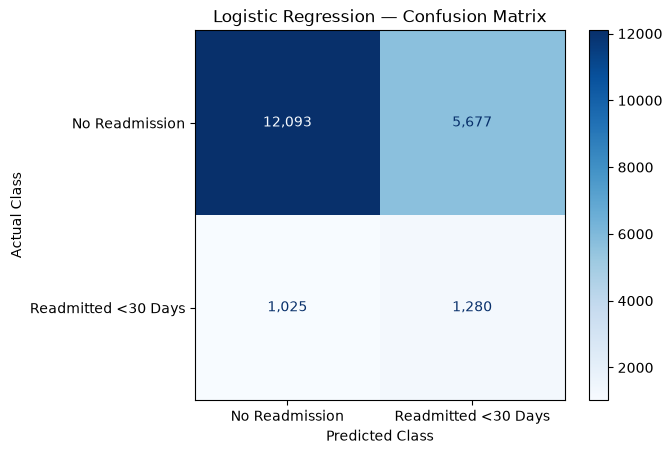

In [146]:
# ============================================================
# VISUAL CONFUSION MATRIX
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=[
        "No Readmission",
        "Readmitted <30 Days"
    ],
    values_format=",",
    cmap="Blues"
)

plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [147]:
# ============================================================
# STANDARD LOGISTIC REGRESSION
# WITHOUT CLASS BALANCING
# ============================================================

logistic_model_standard = LogisticRegression(
    max_iter=2000,
    class_weight=None,
    random_state=42
)

# ============================================================
# STANDARD LOGISTIC REGRESSION PIPELINE
# ============================================================

logistic_pipeline_standard = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            logistic_model_standard
        )
    ]
)

# Train standard Logistic Regression

logistic_pipeline_standard.fit(
    X_train,
    y_train
)

print("=" * 70)
print("STANDARD LOGISTIC REGRESSION TRAINING COMPLETED")
print("=" * 70)

STANDARD LOGISTIC REGRESSION TRAINING COMPLETED


In [ ]:
# Predictions

y_pred_standard = logistic_pipeline_standard.predict(X_test)

y_prob_standard = logistic_pipeline_standard.predict_proba(X_test)[:, 1]


print("=" * 70)
print("LOGISTIC REGRESSION PREDICTIONS GENERATED")
print("=" * 70)

print("\nPrediction shape:", y_pred_standard.shape)
print("Probability shape:", y_prob_standard.shape)

# ============================================================
# LOGISTIC REGRESSION PERFORMANCE METRICS
# ============================================================

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_standard
)

logistic_precision = precision_score(
    y_test,
    y_pred_standard,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    y_pred_standard,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    y_pred_standard,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_standard
)


print("=" * 70)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 70)

print(f"\nAccuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1 Score:  {logistic_f1:.4f}")
print(f"ROC-AUC:   {logistic_roc_auc:.4f}")




LOGISTIC REGRESSION PREDICTIONS GENERATED

Prediction shape: (20075,)
Probability shape: (20075,)
LOGISTIC REGRESSION PERFORMANCE

Accuracy:  0.8855
Precision: 0.5574
Recall:    0.0148
F1 Score:  0.0287
ROC-AUC:   0.6580


In [152]:

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_standard,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17770
           1       0.56      0.01      0.03      2305

    accuracy                           0.89     20075
   macro avg       0.72      0.51      0.48     20075
weighted avg       0.85      0.89      0.83     20075



In [153]:
# ============================================================
# STANDARD LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================================

cm_standard = confusion_matrix(
    y_test,
    y_pred_standard
)

tn_std, fp_std, fn_std, tp_std = cm_standard.ravel()

print("=" * 70)
print("STANDARD LOGISTIC REGRESSION CONFUSION MATRIX")
print("=" * 70)

print("\nConfusion Matrix:")
print(cm_standard)

print("\nClassification Breakdown:")
print(f"True Negatives:  {tn_std:,}")
print(f"False Positives: {fp_std:,}")
print(f"False Negatives: {fn_std:,}")
print(f"True Positives:  {tp_std:,}")


STANDARD LOGISTIC REGRESSION CONFUSION MATRIX

Confusion Matrix:
[[17743    27]
 [ 2271    34]]

Classification Breakdown:
True Negatives:  17,743
False Positives: 27
False Negatives: 2,271
True Positives:  34


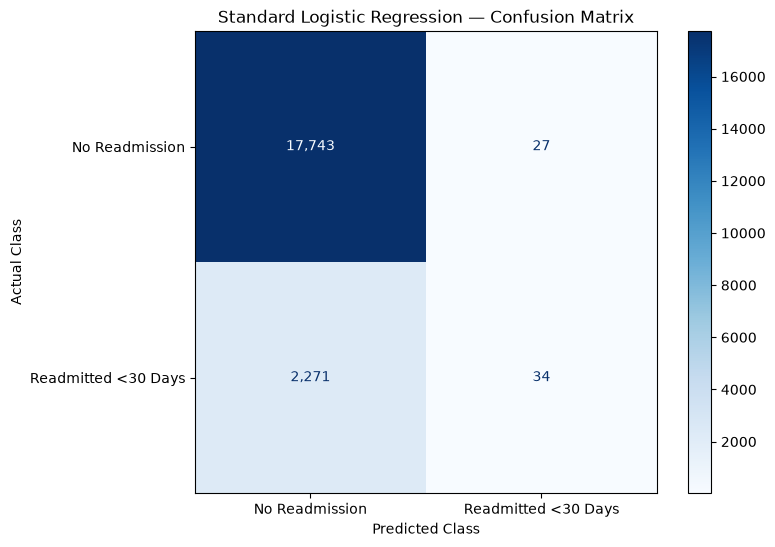

In [154]:
# ============================================================
# VISUAL CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_standard,
    display_labels=[
        "No Readmission",
        "Readmitted <30 Days"
    ],
    values_format=",",
    cmap="Blues",
    ax=ax
)

ax.set_title("Standard Logistic Regression — Confusion Matrix")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

plt.show()

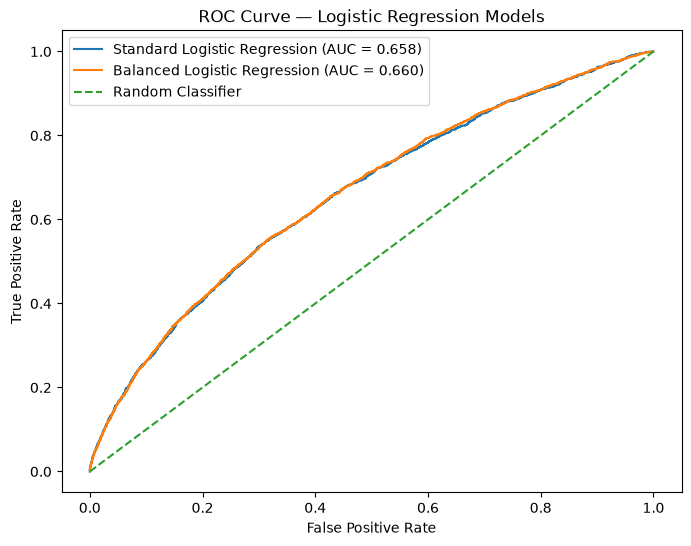

In [156]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

import matplotlib.pyplot as plt


# ============================================================
# ROC CURVE
# ============================================================

# Standard Logistic Regression
fpr_standard, tpr_standard, _ = roc_curve(
    y_test,
    y_prob_standard
)

auc_standard = roc_auc_score(
    y_test,
    y_prob_standard
)


# Balanced Logistic Regression
fpr_balanced, tpr_balanced, _ = roc_curve(
    y_test,
    y_prob_logistic
)

auc_balanced = roc_auc_score(
    y_test,
    y_prob_logistic
)


# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_standard,
    tpr_standard,
    label=f"Standard Logistic Regression (AUC = {auc_standard:.3f})"
)

plt.plot(
    fpr_balanced,
    tpr_balanced,
    label=f"Balanced Logistic Regression (AUC = {auc_balanced:.3f})"
)

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression Models")

plt.legend()
plt.show()

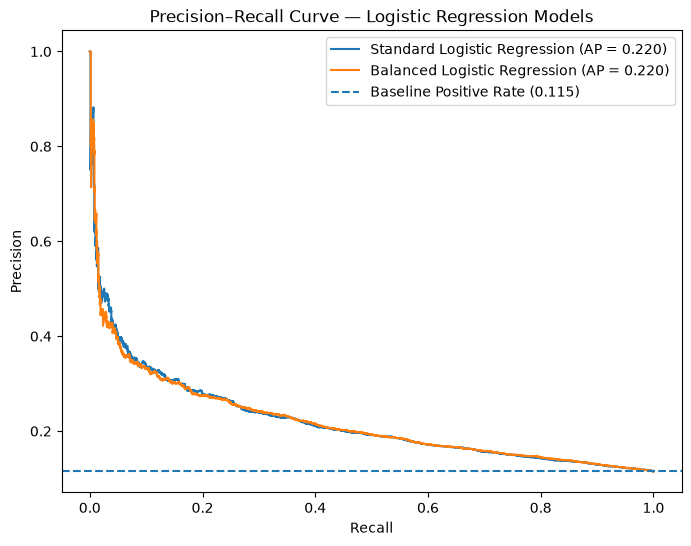

In [157]:
# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

# Standard Logistic Regression
precision_standard, recall_standard, _ = precision_recall_curve(
    y_test,
    y_prob_standard
)

ap_standard = average_precision_score(
    y_test,
    y_prob_standard
)


# Balanced Logistic Regression
precision_balanced, recall_balanced, _ = precision_recall_curve(
    y_test,
    y_prob_logistic
)

ap_balanced = average_precision_score(
    y_test,
    y_prob_logistic
)


# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    recall_standard,
    precision_standard,
    label=f"Standard Logistic Regression (AP = {ap_standard:.3f})"
)

plt.plot(
    recall_balanced,
    precision_balanced,
    label=f"Balanced Logistic Regression (AP = {ap_balanced:.3f})"
)

# Baseline positive rate
baseline = y_test.mean()

plt.axhline(
    y=baseline,
    linestyle="--",
    label=f"Baseline Positive Rate ({baseline:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Logistic Regression Models")

plt.legend()
plt.show()

In [158]:
from sklearn.model_selection import StratifiedGroupKFold

# ============================================================
# 5-FOLD STRATIFIED GROUP CROSS-VALIDATION
# ============================================================

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("=" * 70)
print("5-FOLD STRATIFIED GROUP CROSS-VALIDATION CREATED")
print("=" * 70)

print("Number of folds:", sgkf.n_splits)
print("Grouping variable: patient_nbr")
print("Stratification target: readmitted_30d")

5-FOLD STRATIFIED GROUP CROSS-VALIDATION CREATED
Number of folds: 5
Grouping variable: patient_nbr
Stratification target: readmitted_30d


In [159]:
# ============================================================
# CROSS-VALIDATION FOLD VALIDATION
# ============================================================

print("=" * 70)
print("5-FOLD PATIENT LEAKAGE VALIDATION")
print("=" * 70)

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(X_train, y_train, groups=groups_train),
    start=1
):

    # Get patients in each part of the fold
    fold_train_patients = set(groups_train.iloc[train_idx])
    fold_val_patients = set(groups_train.iloc[val_idx])

    # Check overlap
    patient_overlap = (
        fold_train_patients
        .intersection(fold_val_patients)
    )

    print(f"\nFOLD {fold}")
    print("-" * 70)

    print("Training rows:", len(train_idx))
    print("Validation rows:", len(val_idx))

    print("Training patients:", f"{len(fold_train_patients):,}")
    print("Validation patients:", f"{len(fold_val_patients):,}")

    print(
        "Training positive rate:",
        round(y_train.iloc[train_idx].mean() * 100, 2),
        "%"
    )

    print(
        "Validation positive rate:",
        round(y_train.iloc[val_idx].mean() * 100, 2),
        "%"
    )

    print(
        "Patient overlap:",
        len(patient_overlap)
    )

    assert len(patient_overlap) == 0, \
        f"ERROR — Patient leakage detected in Fold {fold}"

    print("PASS — No patient leakage")

5-FOLD PATIENT LEAKAGE VALIDATION

FOLD 1
----------------------------------------------------------------------
Training rows: 64033
Validation rows: 16006
Training patients: 45,047
Validation patients: 11,304
Training positive rate: 11.31 %
Validation positive rate: 11.31 %
Patient overlap: 0
PASS — No patient leakage

FOLD 2
----------------------------------------------------------------------
Training rows: 64027
Validation rows: 16012
Training patients: 45,080
Validation patients: 11,271
Training positive rate: 11.31 %
Validation positive rate: 11.32 %
Patient overlap: 0
PASS — No patient leakage

FOLD 3
----------------------------------------------------------------------
Training rows: 64031
Validation rows: 16008
Training patients: 45,064
Validation patients: 11,287
Training positive rate: 11.31 %
Validation positive rate: 11.31 %
Patient overlap: 0
PASS — No patient leakage

FOLD 4
----------------------------------------------------------------------
Training rows: 64033
Va

In [160]:
# ============================================================
# STANDARD LOGISTIC REGRESSION PIPELINE
# ============================================================

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                class_weight=None,
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [161]:
print("=" * 70)
print("LOGISTIC REGRESSION PIPELINE CREATED")
print("=" * 70)

print(logistic_pipeline)

LOGISTIC REGRESSION PIPELINE CREATED
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                         

In [162]:
# ============================================================
# 5-FOLD GROUPED CROSS-VALIDATION
# STANDARD LOGISTIC REGRESSION
# ============================================================
from sklearn.base import clone

cv_results = []

print("=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("MODEL: STANDARD LOGISTIC REGRESSION")
print("=" * 70)

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(X_train, y_train, groups=groups_train),
    start=1
):

    print(f"\nTraining Fold {fold}...")

    # --------------------------------------------------------
    # Split current fold
    # --------------------------------------------------------

    X_train_fold = X_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]

    y_train_fold = y_train.iloc[train_idx]
    y_val_fold = y_train.iloc[val_idx]

    # --------------------------------------------------------
    # Create a fresh pipeline for each fold
    # --------------------------------------------------------

    model = clone(logistic_pipeline)

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(
        X_train_fold,
        y_train_fold
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_pred = model.predict(X_val_fold)

    y_prob = model.predict_proba(X_val_fold)[:, 1]

    # --------------------------------------------------------
    # Calculate metrics
    # --------------------------------------------------------

    fold_metrics = {
        "fold": fold,
        "accuracy": accuracy_score(
            y_val_fold,
            y_pred
        ),
        "precision": precision_score(
            y_val_fold,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_val_fold,
            y_pred,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_val_fold,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_val_fold,
            y_prob
        ),
        "average_precision": average_precision_score(
            y_val_fold,
            y_prob
        )
    }

    cv_results.append(fold_metrics)

    print(
        f"Fold {fold} completed | "
        f"ROC-AUC: {fold_metrics['roc_auc']:.4f} | "
        f"Recall: {fold_metrics['recall']:.4f} | "
        f"F1: {fold_metrics['f1_score']:.4f}"
    )

5-FOLD CROSS-VALIDATION
MODEL: STANDARD LOGISTIC REGRESSION

Training Fold 1...
Fold 1 completed | ROC-AUC: 0.6688 | Recall: 0.0199 | F1: 0.0382

Training Fold 2...
Fold 2 completed | ROC-AUC: 0.6668 | Recall: 0.0177 | F1: 0.0340

Training Fold 3...
Fold 3 completed | ROC-AUC: 0.6553 | Recall: 0.0122 | F1: 0.0236

Training Fold 4...
Fold 4 completed | ROC-AUC: 0.6666 | Recall: 0.0271 | F1: 0.0513

Training Fold 5...
Fold 5 completed | ROC-AUC: 0.6612 | Recall: 0.0149 | F1: 0.0289


In [163]:
# ============================================================
# CROSS-VALIDATION RESULTS
# ============================================================

cv_results_df = pd.DataFrame(cv_results)

print("\n" + "=" * 70)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

display(
    cv_results_df.round(4)
)



5-FOLD CROSS-VALIDATION RESULTS


,fold,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,1,0.8867,0.4800,0.0199,0.0382,0.6688,0.2236
1,2,0.8864,0.4507,0.0177,0.0340,0.6668,0.2190
2,3,0.8864,0.4231,0.0122,0.0236,0.6553,0.2029
3,4,0.8869,0.4949,0.0271,0.0513,0.6666,0.2239
4,5,0.8867,0.4655,0.0149,0.0289,0.6612,0.2054


In [164]:
# ============================================================
# CROSS-VALIDATION SUMMARY
# ============================================================

cv_summary = pd.DataFrame({
    "Mean": cv_results_df.drop(columns="fold").mean(),
    "Std": cv_results_df.drop(columns="fold").std()
})

cv_summary["Mean ± Std"] = (
    cv_summary["Mean"].round(4).astype(str)
    + " ± "
    + cv_summary["Std"].round(4).astype(str)
)

print("=" * 70)
print("STANDARD LOGISTIC REGRESSION — CV SUMMARY")
print("=" * 70)

display(cv_summary)

STANDARD LOGISTIC REGRESSION — CV SUMMARY


,Mean,Std,Mean ± Std
accuracy,0.886618,0.000197,0.8866 ± 0.0002
precision,0.462850,0.027663,0.4628 ± 0.0277
recall,0.018339,0.005681,0.0183 ± 0.0057
f1_score,0.035212,0.010539,0.0352 ± 0.0105
roc_auc,0.663757,0.005479,0.6638 ± 0.0055
average_precision,0.214988,0.010097,0.215 ± 0.0101


In [165]:
# ============================================================
# BALANCED LOGISTIC REGRESSION PIPELINE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

balanced_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

print("=" * 70)
print("BALANCED LOGISTIC REGRESSION PIPELINE CREATED")
print("=" * 70)

print("\nClass weight: balanced")
print("Cross-validation: 5-fold StratifiedGroupKFold")
print("Patient grouping: preserved")

BALANCED LOGISTIC REGRESSION PIPELINE CREATED

Class weight: balanced
Cross-validation: 5-fold StratifiedGroupKFold
Patient grouping: preserved


In [166]:
# ============================================================
# 5-FOLD GROUPED CROSS-VALIDATION
# BALANCED LOGISTIC REGRESSION
# ============================================================

balanced_cv_results = []

print("=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("MODEL: BALANCED LOGISTIC REGRESSION")
print("=" * 70)

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(X_train, y_train, groups=groups_train),
    start=1
):

    print(f"\nTraining Fold {fold}...")

    # --------------------------------------------------------
    # Split current fold
    # --------------------------------------------------------

    X_train_fold = X_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]

    y_train_fold = y_train.iloc[train_idx]
    y_val_fold = y_train.iloc[val_idx]

    # --------------------------------------------------------
    # Create fresh model for each fold
    # --------------------------------------------------------

    model = clone(balanced_logistic_pipeline)

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(
        X_train_fold,
        y_train_fold
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_pred = model.predict(X_val_fold)

    y_prob = model.predict_proba(X_val_fold)[:, 1]

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    fold_metrics = {
        "fold": fold,
        "accuracy": accuracy_score(y_val_fold, y_pred),
        "precision": precision_score(
            y_val_fold,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_val_fold,
            y_pred,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_val_fold,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_val_fold,
            y_prob
        ),
        "average_precision": average_precision_score(
            y_val_fold,
            y_prob
        )
    }

    balanced_cv_results.append(fold_metrics)

    print(
        f"Fold {fold} completed | "
        f"ROC-AUC: {fold_metrics['roc_auc']:.4f} | "
        f"Recall: {fold_metrics['recall']:.4f} | "
        f"F1: {fold_metrics['f1_score']:.4f}"
    )

5-FOLD CROSS-VALIDATION
MODEL: BALANCED LOGISTIC REGRESSION

Training Fold 1...
Fold 1 completed | ROC-AUC: 0.6687 | Recall: 0.5569 | F1: 0.2753

Training Fold 2...
Fold 2 completed | ROC-AUC: 0.6701 | Recall: 0.5679 | F1: 0.2792

Training Fold 3...
Fold 3 completed | ROC-AUC: 0.6573 | Recall: 0.5414 | F1: 0.2708

Training Fold 4...
Fold 4 completed | ROC-AUC: 0.6683 | Recall: 0.5580 | F1: 0.2703

Training Fold 5...
Fold 5 completed | ROC-AUC: 0.6633 | Recall: 0.5470 | F1: 0.2688


In [167]:
# ============================================================
# BALANCED LOGISTIC REGRESSION CV RESULTS
# ============================================================

balanced_cv_results_df = pd.DataFrame(balanced_cv_results)

print("\n" + "=" * 70)
print("BALANCED LOGISTIC REGRESSION")
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

display(
    balanced_cv_results_df.round(4)
)


BALANCED LOGISTIC REGRESSION
5-FOLD CROSS-VALIDATION RESULTS


,fold,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,1,0.6684,0.1828,0.5569,0.2753,0.6687,0.2224
1,2,0.6682,0.1851,0.5679,0.2792,0.6701,0.2195
2,3,0.6703,0.1805,0.5414,0.2708,0.6573,0.2032
3,4,0.6594,0.1784,0.5580,0.2703,0.6683,0.2234
4,5,0.6635,0.1782,0.5470,0.2688,0.6633,0.2058


In [168]:
# ============================================================
# BALANCED LOGISTIC REGRESSION CV SUMMARY
# ============================================================

balanced_cv_summary = pd.DataFrame({
    "Mean": balanced_cv_results_df
        .drop(columns="fold")
        .mean(),

    "Std": balanced_cv_results_df
        .drop(columns="fold")
        .std()
})

balanced_cv_summary["Mean ± Std"] = (
    balanced_cv_summary["Mean"]
        .round(4)
        .astype(str)
    + " ± "
    + balanced_cv_summary["Std"]
        .round(4)
        .astype(str)
)

print("=" * 70)
print("BALANCED LOGISTIC REGRESSION — CV SUMMARY")
print("=" * 70)

display(balanced_cv_summary)

BALANCED LOGISTIC REGRESSION — CV SUMMARY


,Mean,Std,Mean ± Std
accuracy,0.665950,0.004456,0.666 ± 0.0045
precision,0.181005,0.002975,0.181 ± 0.003
recall,0.554239,0.010299,0.5542 ± 0.0103
f1_score,0.272880,0.004288,0.2729 ± 0.0043
roc_auc,0.665540,0.005275,0.6655 ± 0.0053
average_precision,0.214842,0.009601,0.2148 ± 0.0096


In [169]:
# ============================================================
# BALANCED LOGISTIC REGRESSION
# FINAL TRAINING ON FULL TRAINING DATA
# ============================================================

from sklearn.base import clone

final_balanced_logistic_model = clone(
    balanced_logistic_pipeline
)

final_balanced_logistic_model.fit(
    X_train,
    y_train
)

print("=" * 70)
print("FINAL BALANCED LOGISTIC REGRESSION TRAINING COMPLETED")
print("=" * 70)
print(f"\nTraining samples: {X_train.shape[0]:,}")
print(f"Training features: {X_train.shape[1]}")

FINAL BALANCED LOGISTIC REGRESSION TRAINING COMPLETED

Training samples: 80,039
Training features: 39


In [170]:
# ============================================================
# BALANCED LOGISTIC REGRESSION
# TEST SET PREDICTIONS
# ============================================================

y_pred_balanced = final_balanced_logistic_model.predict(
    X_test
)

y_prob_balanced = final_balanced_logistic_model.predict_proba(
    X_test
)[:, 1]

print("=" * 70)
print("BALANCED LOGISTIC REGRESSION PREDICTIONS GENERATED")
print("=" * 70)

print(f"\nPrediction shape: {y_pred_balanced.shape}")
print(f"Probability shape: {y_prob_balanced.shape}")

BALANCED LOGISTIC REGRESSION PREDICTIONS GENERATED

Prediction shape: (20075,)
Probability shape: (20075,)


In [172]:
# ============================================================
# BALANCED LOGISTIC REGRESSION PERFORMANCE
# ============================================================

balanced_accuracy = accuracy_score(
    y_test,
    y_pred_balanced
)

balanced_precision = precision_score(
    y_test,
    y_pred_balanced,
    zero_division=0
)

balanced_recall = recall_score(
    y_test,
    y_pred_balanced,
    zero_division=0
)

balanced_f1 = f1_score(
    y_test,
    y_pred_balanced,
    zero_division=0
)

balanced_roc_auc = roc_auc_score(
    y_test,
    y_prob_balanced
)

balanced_avg_precision = average_precision_score(
    y_test,
    y_prob_balanced
)

print("=" * 70)
print("BALANCED LOGISTIC REGRESSION PERFORMANCE")
print("=" * 70)

print(f"\nAccuracy:          {balanced_accuracy:.4f}")
print(f"Precision:         {balanced_precision:.4f}")
print(f"Recall:            {balanced_recall:.4f}")
print(f"F1 Score:          {balanced_f1:.4f}")
print(f"ROC-AUC:           {balanced_roc_auc:.4f}")
print(f"Average Precision: {balanced_avg_precision:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_balanced,
        digits=4,
        zero_division=0
    )
)

BALANCED LOGISTIC REGRESSION PERFORMANCE

Accuracy:          0.6662
Precision:         0.1840
Recall:            0.5553
F1 Score:          0.2764
ROC-AUC:           0.6600
Average Precision: 0.2196

Classification Report:
              precision    recall  f1-score   support

           0     0.9219    0.6805    0.7830     17770
           1     0.1840    0.5553    0.2764      2305

    accuracy                         0.6662     20075
   macro avg     0.5529    0.6179    0.5297     20075
weighted avg     0.8371    0.6662    0.7249     20075



In [173]:
# ============================================================
# BALANCED LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm_balanced = confusion_matrix(
    y_test,
    y_pred_balanced
)

tn, fp, fn, tp = cm_balanced.ravel()

print("=" * 70)
print("BALANCED LOGISTIC REGRESSION CONFUSION MATRIX")
print("=" * 70)

print("\nConfusion Matrix:")
print(cm_balanced)

print("\nClassification Breakdown:")
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

BALANCED LOGISTIC REGRESSION CONFUSION MATRIX

Confusion Matrix:
[[12093  5677]
 [ 1025  1280]]

Classification Breakdown:
True Negatives:  12,093
False Positives: 5,677
False Negatives: 1,025
True Positives:  1,280


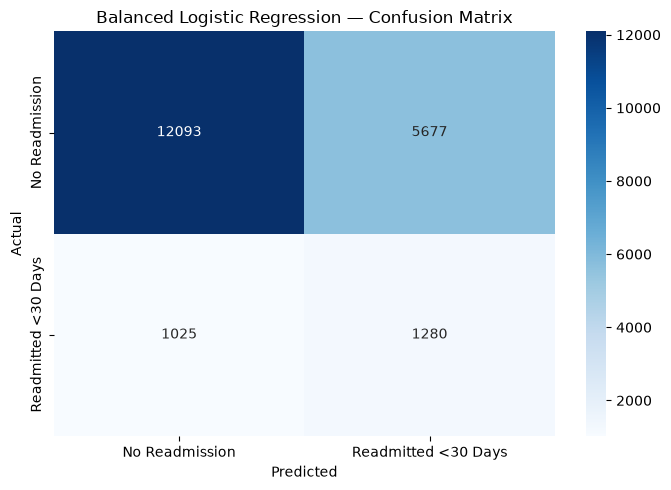

In [174]:
# ============================================================
# BALANCED LOGISTIC REGRESSION
# CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Readmission", "Readmitted <30 Days"],
    yticklabels=["No Readmission", "Readmitted <30 Days"]
)

plt.title("Balanced Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()